In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

In [3]:
day_0 = pd.read_csv("prices_round_3_day_0.csv", sep=';')
day_1 = pd.read_csv("prices_round_3_day_1.csv", sep=';')
day_2 = pd.read_csv("prices_round_3_day_2.csv", sep=';')


day_1['timestamp'] += day_0['timestamp'].max() + 1
day_2['timestamp'] += day_1['timestamp'].max() + 1

combined_df = pd.concat([day_0,day_1,day_2], ignore_index=True)
max(combined_df['timestamp'])


2999702

In [4]:
combined_df

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,VOLCANIC_ROCK_VOUCHER_10500,99.0,19.0,NaN,NaN,NaN,NaN,100,19,NaN,NaN,NaN,NaN,99.5,0.0
1,0,0,DJEMBES,13493.0,72.0,NaN,NaN,NaN,NaN,13494,72,NaN,NaN,NaN,NaN,13493.5,0.0
2,0,0,CROISSANTS,4321.0,111.0,NaN,NaN,NaN,NaN,4322,111,NaN,NaN,NaN,NaN,4321.5,0.0
3,0,0,JAMS,6631.0,210.0,NaN,NaN,NaN,NaN,6633,210,NaN,NaN,NaN,NaN,6632.0,0.0
4,0,0,VOLCANIC_ROCK_VOUCHER_10000,505.0,19.0,NaN,NaN,NaN,NaN,506,19,NaN,NaN,NaN,NaN,505.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419995,2,2999702,PICNIC_BASKET2,30073.0,1.0,30072.0,39.0,NaN,NaN,30078,20,30079.0,20.0,NaN,NaN,30075.5,0.0
419996,2,2999702,VOLCANIC_ROCK_VOUCHER_9750,417.0,20.0,NaN,NaN,NaN,NaN,418,20,NaN,NaN,NaN,NaN,417.5,0.0
419997,2,2999702,PICNIC_BASKET1,58422.0,1.0,58421.0,39.0,NaN,NaN,58432,20,58433.0,20.0,NaN,NaN,58427.0,0.0
419998,2,2999702,CROISSANTS,4241.0,143.0,NaN,NaN,NaN,NaN,4242,143,NaN,NaN,NaN,NaN,4241.5,0.0


In [5]:
def extract_prices(df, symbol):
    filtered = df[df['product'] == symbol]
    prices_only = filtered[['timestamp', 'mid_price']]
    return prices_only

def calculate_mid_price(row):
    best_bid = row['bid_price_1']
    best_ask = row['ask_price_1']
    
    # Gestion des valeurs manquantes potentielles
    if pd.notna(best_bid) and pd.notna(best_ask):
        return (best_bid + best_ask) / 2
    elif pd.notna(best_bid):
        return best_bid
    elif pd.notna(best_ask):
        return best_ask
    else:
        return None


combined_df['mid_price'] = combined_df.apply(calculate_mid_price, axis=1)



In [6]:
rock_mid_prices = extract_prices(combined_df, 'VOLCANIC_ROCK')
voucher_9500_mid_prices = extract_prices(combined_df, "VOLCANIC_ROCK_VOUCHER_9500")
voucher_9750_mid_prices = extract_prices(combined_df, 'VOLCANIC_ROCK_VOUCHER_9750') 
voucher_10000_mid_prices = extract_prices(combined_df, 'VOLCANIC_ROCK_VOUCHER_10000')
voucher_10250_mid_prices = extract_prices(combined_df, 'VOLCANIC_ROCK_VOUCHER_10250')
voucher_10500_mid_prices = extract_prices(combined_df, 'VOLCANIC_ROCK_VOUCHER_10500')
croissants_prices = extract_prices(combined_df, 'CROISSANTS')
jams_prices = extract_prices(combined_df, 'JAMS')
basket2_prices = extract_prices(combined_df, 'PICNIC_BASKET2')
basket1_prices = extract_prices(combined_df, 'PICNIC_BASKET1')


In [7]:
b2p_indexed = basket2_prices.set_index('timestamp')
cp_indexed = croissants_prices.set_index('timestamp')
jp_indexed = jams_prices.set_index('timestamp')
synthetic = 4 * cp_indexed['mid_price'] + 2 * jp_indexed['mid_price']
synthetic = synthetic.rename('synthetic_price')
basket2_prices_updated = b2p_indexed.join(synthetic, how='inner')
basket2_prices_final = basket2_prices_updated.reset_index()





--- Calibration sur les prix ---
Kappa (κ): 0.000107 (force de retour à la moyenne)
Theta (θ): 58490.960337 (niveau moyen à long terme)
Sigma (σ): 4.224457 (volatilité)

Test ADF (stationnarité) p-value: 0.568858
→ La série n'est pas stationnaire (p>0.05), ce qui est problématique pour Vasicek

--- Calibration sur les rendements logarithmiques ---
Kappa (κ): 1.040775
Theta (θ): -0.000000
Sigma (σ): 0.000072

Test ADF (stationnarité) p-value: 0.000000
→ Les rendements sont stationnaires (p<0.05), meilleur pour Vasicek

--- Comparaison et Recommandation ---
Le modèle calibré sur les prix indique une absence de retour à la moyenne significatif.
Cela suggère que les prix suivent plutôt une marche aléatoire qu'un processus de Vasicek.

RECOMMANDATION: Le modèle de Vasicek est plus approprié pour les rendements que pour les prix.
- Utiliser: κ=1.040775, θ=-0.000000, σ=0.000072


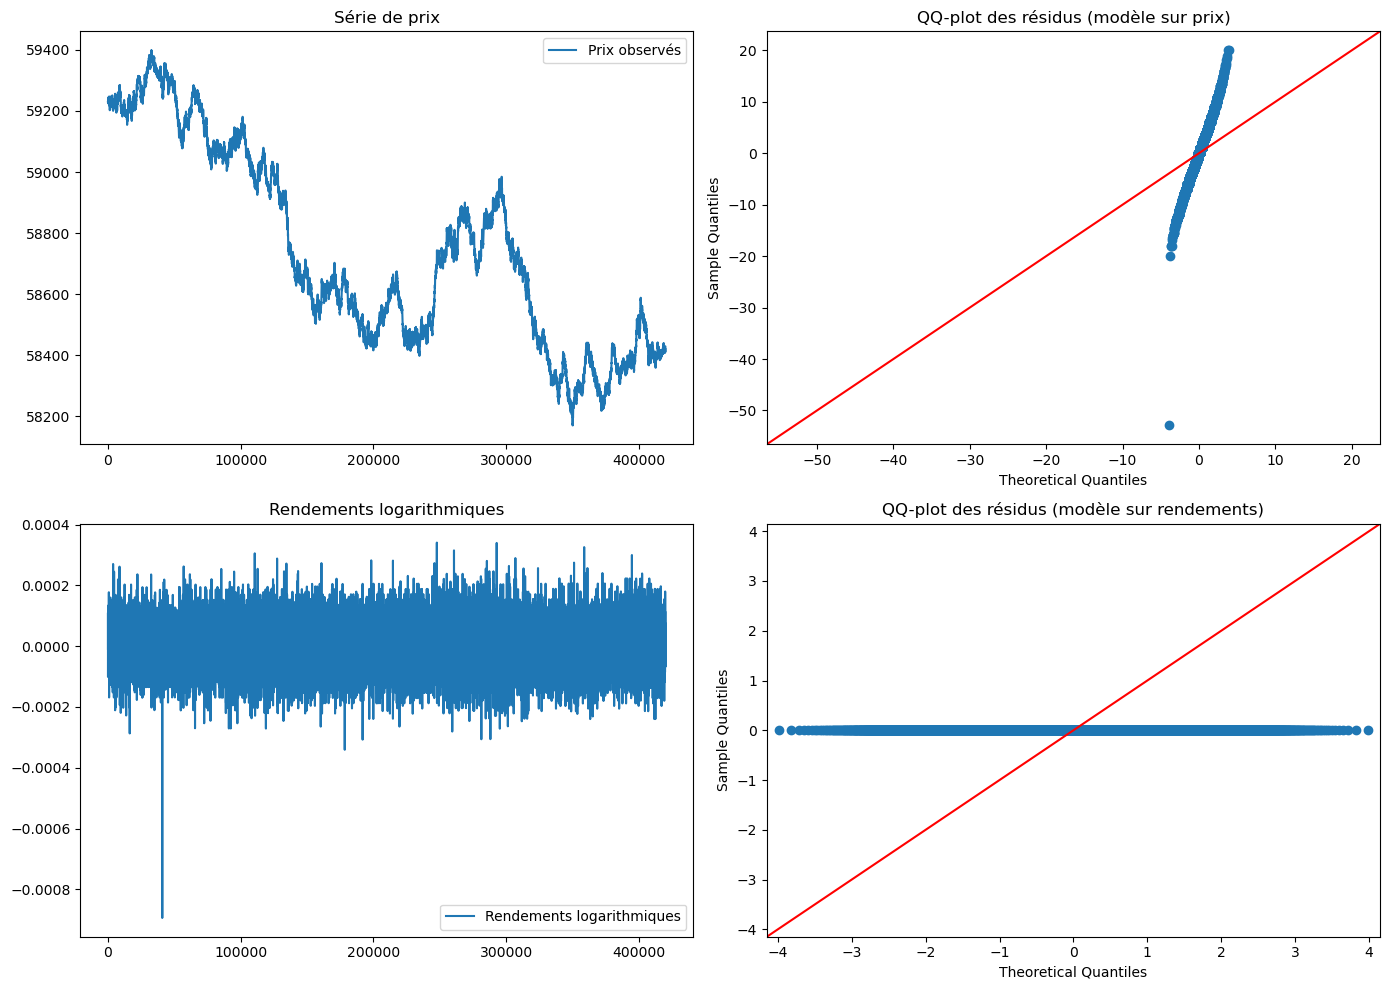

In [8]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats

# Supposons que basket1_prices est déjà défini avec vos données
# Si nous devons travailler avec les rendements plutôt que les prix bruts

# 1. Préparation des données
# Assurons-nous que les prix sont numériques
basket1_prices['mid_price'] = pd.to_numeric(basket1_prices['mid_price'], errors='coerce')
df_cleaned = basket1_prices.dropna(subset=['mid_price'])

# 2. Calibration sur les prix (comme dans votre code initial)
def calibrate_vasicek_prices(df):
    y = df['mid_price']
    X_shifted = df['mid_price'].shift(1)
    X = sm.add_constant(X_shifted)
    
    model = sm.OLS(y, X, missing='drop')
    results = model.fit()
    
    intercept, slope = results.params
    residuals_std = np.std(results.resid)
    dt = 1  # Ajustez selon la fréquence des données
    
    kappa = (1 - slope) / dt
    if np.isclose(kappa, 0, atol=1e-5):
        theta = np.nan
    else:
        theta = intercept / (kappa * dt)
    
    sigma = residuals_std / np.sqrt(dt)
    
    print("\n--- Calibration sur les prix ---")
    print(f"Kappa (κ): {kappa:.6f} (force de retour à la moyenne)")
    print(f"Theta (θ): {theta:.6f} (niveau moyen à long terme)")
    print(f"Sigma (σ): {sigma:.6f} (volatilité)")
    
    # Test de stationnarité
    from statsmodels.tsa.stattools import adfuller
    adf_result = adfuller(df['mid_price'].dropna())
    print(f"\nTest ADF (stationnarité) p-value: {adf_result[1]:.6f}")
    if adf_result[1] > 0.05:
        print("→ La série n'est pas stationnaire (p>0.05), ce qui est problématique pour Vasicek")
    else:
        print("→ La série est stationnaire (p<0.05), compatible avec Vasicek")
    
    return results, kappa, theta, sigma

# 3. Calibration sur les rendements (logarithmiques)
def calibrate_vasicek_returns(df):
    # Calculer les rendements logarithmiques
    df['log_returns'] = np.log(df['mid_price'] / df['mid_price'].shift(1))
    
    y = df['log_returns'].dropna()
    X_shifted = df['log_returns'].shift(1).dropna()
    
    # Alignement des données
    aligned_data = pd.DataFrame({'y': y[1:], 'X_shifted': X_shifted[:-1]})
    aligned_data = aligned_data.dropna()
    
    X = sm.add_constant(aligned_data['X_shifted'])
    y = aligned_data['y']
    
    model = sm.OLS(y, X)
    results = model.fit()
    
    intercept, slope = results.params
    residuals_std = np.std(results.resid)
    dt = 1
    
    kappa_returns = (1 - slope) / dt
    if np.isclose(kappa_returns, 0, atol=1e-5):
        theta_returns = np.nan
    else:
        theta_returns = intercept / (kappa_returns * dt)
    
    sigma_returns = residuals_std / np.sqrt(dt)
    
    print("\n--- Calibration sur les rendements logarithmiques ---")
    print(f"Kappa (κ): {kappa_returns:.6f}")
    print(f"Theta (θ): {theta_returns:.6f}")
    print(f"Sigma (σ): {sigma_returns:.6f}")
    
    # Test de stationnarité sur les rendements
    from statsmodels.tsa.stattools import adfuller
    adf_result = adfuller(df['log_returns'].dropna())
    print(f"\nTest ADF (stationnarité) p-value: {adf_result[1]:.6f}")
    if adf_result[1] > 0.05:
        print("→ Les rendements ne sont pas stationnaires (p>0.05)")
    else:
        print("→ Les rendements sont stationnaires (p<0.05), meilleur pour Vasicek")
    
    return results, kappa_returns, theta_returns, sigma_returns

# 4. Diagnostics visuels
def plot_diagnostics(df, results_prices, results_returns):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Prix et simulation
    axes[0, 0].plot(df['mid_price'], label='Prix observés')
    axes[0, 0].set_title('Série de prix')
    axes[0, 0].legend()
    
    # QQ-plot des résidus (prix)
    sm.qqplot(results_prices.resid, line='45', ax=axes[0, 1])
    axes[0, 1].set_title('QQ-plot des résidus (modèle sur prix)')
    
    # Rendements
    df['log_returns'] = np.log(df['mid_price'] / df['mid_price'].shift(1))
    axes[1, 0].plot(df['log_returns'].dropna(), label='Rendements logarithmiques')
    axes[1, 0].set_title('Rendements logarithmiques')
    axes[1, 0].legend()
    
    # QQ-plot des résidus (rendements)
    if results_returns is not None:
        sm.qqplot(results_returns.resid, line='45', ax=axes[1, 1])
        axes[1, 1].set_title('QQ-plot des résidus (modèle sur rendements)')
    
    plt.tight_layout()
    plt.show()

# 5. Exécution
try:
    # Calibration sur les prix
    results_prices, kappa, theta, sigma = calibrate_vasicek_prices(df_cleaned)
    
    # Calibration sur les rendements
    results_returns, kappa_returns, theta_returns, sigma_returns = calibrate_vasicek_returns(df_cleaned)
    
    # Comparaison et recommandation
    print("\n--- Comparaison et Recommandation ---")
    if np.isnan(theta) or kappa < 0.01:
        print("Le modèle calibré sur les prix indique une absence de retour à la moyenne significatif.")
        print("Cela suggère que les prix suivent plutôt une marche aléatoire qu'un processus de Vasicek.")
    
    # Validation du modèle sur les rendements
    from statsmodels.tsa.stattools import adfuller
    adf_price = adfuller(df_cleaned['mid_price'].dropna())[1]
    adf_returns = adfuller(df_cleaned['log_returns'].dropna())[1]
    
    if adf_returns < 0.05 and adf_price >= 0.05:
        print("\nRECOMMANDATION: Le modèle de Vasicek est plus approprié pour les rendements que pour les prix.")
        print(f"- Utiliser: κ={kappa_returns:.6f}, θ={theta_returns:.6f}, σ={sigma_returns:.6f}")
    elif kappa > kappa_returns and kappa > 0.01:
        print("\nRECOMMANDATION: Le modèle de Vasicek sur les prix montre un retour à la moyenne plus fort.")
        print(f"- Utiliser: κ={kappa:.6f}, θ={theta:.6f}, σ={sigma:.6f}")
    else:
        print("\nRECOMMANDATION: Considérer un modèle alternatif (marche aléatoire ou GARCH)")
        print("Les deux approches montrent un très faible retour à la moyenne.")
    
    # Visualisation
    plot_diagnostics(df_cleaned, results_prices, results_returns)
    
except Exception as e:
    print(f"Erreur lors de la calibration: {e}")
    # Si les rendements échouent, essayons au moins la calibration sur les prix
    try:
        results_prices, kappa, theta, sigma = calibrate_vasicek_prices(df_cleaned)
        plot_diagnostics(df_cleaned, results_prices, None)
    except Exception as e2:
        print(f"Échec de la calibration sur les prix également: {e2}")

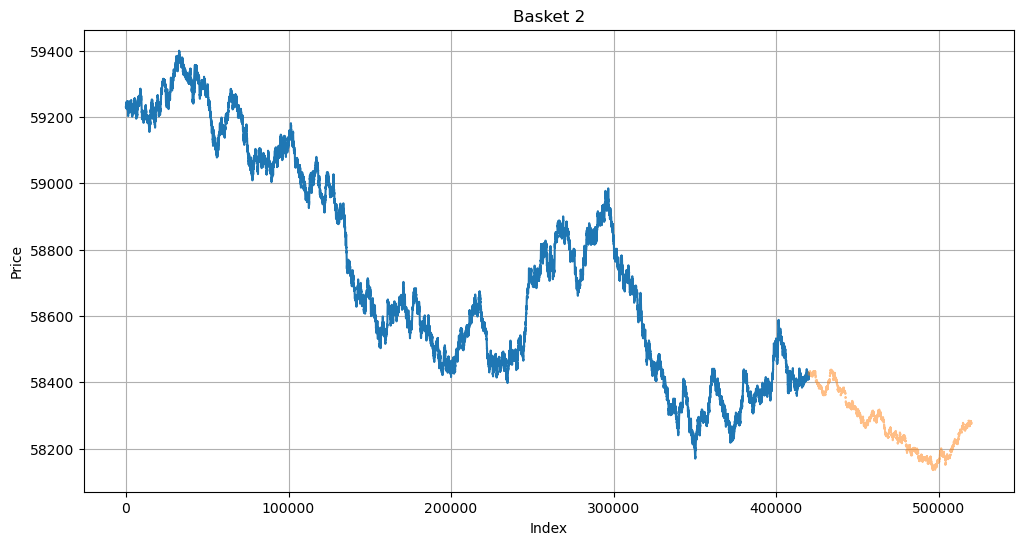

In [ ]:
num_simulations = 1
num_steps = 100000 
last_spread = df_cleaned['mid_price'].iloc[-1]
dt = 1

plt.figure(figsize=(12, 6))
# Tracer l'historique
plt.plot(df_cleaned.index, df_cleaned['mid_price'], label='Spread Observé Historique')

# Simuler et tracer les trajectoires
for _ in range(num_simulations):
    simulated_path = [last_spread]
    current_spread = last_spread
    for i in range(num_steps):
        # Formule discrétisée de Vasicek
        dW = np.random.normal(0, np.sqrt(dt)) # Mouvement Brownien
        dSpread = kappa * (theta - current_spread) * dt + sigma * dW
        current_spread += dSpread
        simulated_path.append(current_spread)

    # Créer un index pour les points simulés
    sim_index = range(df_cleaned.index[-1], df_cleaned.index[-1] + num_steps + 1)
    plt.plot(sim_index, simulated_path, linestyle=':', alpha=0.5) # alpha pour transparence

plt.title(f'Basket 2')
plt.xlabel('Index')
plt.ylabel('Price')

plt.grid(True)

plt.show()



# Options

In [10]:
voucher_9500_mid_prices = pd.merge_asof(
    rock_mid_prices.rename(columns={'mid_price': 'spot'}),
    voucher_9500_mid_prices.rename(columns={'mid_price': 'mid_price'}),
    on="timestamp",
    direction='nearest'
)

# Merge avec call_9750
voucher_9750_mid_prices = pd.merge_asof(
    rock_mid_prices.rename(columns={'mid_price': 'spot'}),
    voucher_9750_mid_prices.rename(columns={'mid_price': 'mid_price'}),
    on="timestamp",
    direction='nearest'
)

# Merge avec call_10000
voucher_10000_mid_prices = pd.merge_asof(
    rock_mid_prices.rename(columns={'mid_price': 'spot'}),
    voucher_10000_mid_prices.rename(columns={'mid_price': 'mid_price'}),
    on="timestamp",
    direction='nearest'
)

# Merge avec call_10250
voucher_10250_mid_prices = pd.merge_asof(
    rock_mid_prices.rename(columns={'mid_price': 'spot'}),
    voucher_10250_mid_prices.rename(columns={'mid_price': 'mid_price'}),
    on="timestamp",
    direction='nearest'
)

# Merge avec call_10500
voucher_10500_mid_prices = pd.merge_asof(
    rock_mid_prices.rename(columns={'mid_price': 'spot'}),
    voucher_10500_mid_prices.rename(columns={'mid_price': 'mid_price'}),
    on="timestamp",
    direction='nearest'
)

In [11]:
from scipy.stats import norm
from scipy import optimize

def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def calculate_implied_vol(price, S, K, T, r):
    def objective(sigma):
        return black_scholes_call(S, K, T, r, sigma) - price
    
    try:
        result = optimize.brentq(objective, 0.001, 5.0)
        return result
    except:
        return np.nan

def calculate_greeks(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    delta = norm.cdf(d1)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    theta = -S * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
    vega = S * norm.pdf(d1) * np.sqrt(T) / 100
    rho = K * T * np.exp(-r * T) * norm.cdf(d2) / 100
    
    return delta, gamma, theta, vega, rho

In [12]:
def process_option_data(df, strike, r=0.00):
    df = df.copy()
    DAYS_TO_EXPIRY = 7
    DAYS_TO_EXPIRY = 7
    TICKS_PER_DAY = 1000000
    
    
    df['days_remaining'] = DAYS_TO_EXPIRY - (df['timestamp'] / TICKS_PER_DAY)
    df['T'] = df['days_remaining'] / 365
    
    
   
    df = df[(df['T'] > 0) & (df['spot'] > 0) & (df['mid_price'] > 0)]

    df['iv'] = df.apply(lambda row: calculate_implied_vol(row['mid_price'], row['spot'], strike, row['T'], r), axis=1)
    
    # Calculer les grecques
    greeks = df.apply(lambda row: calculate_greeks(row['spot'], strike, row['T'], r, row['iv']) 
                     if not np.isnan(row['iv']) else (np.nan, np.nan, np.nan, np.nan, np.nan), axis=1)
    
    df['delta'] = [g[0] for g in greeks]
    df['gamma'] = [g[1] for g in greeks]
    df['theta'] = [g[2] for g in greeks]
    df['vega'] = [g[3] for g in greeks]
    
    return df

In [13]:
voucher_9500_analysis= pd.read_excel("voucher_9500_analysis.xlsx")
voucher_9750_analysis =pd.read_excel("voucher_9750_analysis.xlsx")
voucher_10000_analysis=pd.read_excel("voucher_10000_analysis.xlsx")
voucher_10250_analysis=pd.read_excel("voucher_12500_analysis.xlsx")
voucher_10500_analysis=pd.read_excel("voucher_10500_analysis.xlsx")


In [14]:
voucher_10000_analysis

,Unnamed: 0,timestamp,spot,mid_price,days_remaining,T,iv,delta,gamma,theta,vega
0,0,0,10503.0,505.5,7.000000,0.019178,0.181718,0.975161,0.000220,-400.560360,0.845485
1,1,100,10510.0,515.5,6.999900,0.019178,0.211398,0.956713,0.000299,-736.941189,1.337090
2,2,200,10513.0,516.5,6.999800,0.019178,0.195405,0.968717,0.000248,-522.480379,1.025548
3,3,300,10517.5,521.5,6.999700,0.019177,0.201485,0.965792,0.000258,-580.198212,1.104462
4,4,400,10509.5,512.5,6.999600,0.019177,0.189258,0.971883,0.000234,-463.019727,0.938331
...,...,...,...,...,...,...,...,...,...,...,...
29995,29995,2999302,10168.0,182.5,4.000698,0.010961,0.161094,0.840441,0.001416,-1899.948479,2.585449
29996,29996,2999402,10167.0,184.5,4.000598,0.010961,0.171695,0.823911,0.001416,-2157.519700,2.754598
29997,29997,2999502,10167.0,182.5,4.000498,0.010960,0.164297,0.834347,0.001423,-1985.419576,2.648948
29998,29998,2999602,10167.5,185.5,4.000398,0.010960,0.173828,0.821711,0.001410,-2201.679281,2.776353


Text(0, 0.5, 'Volatilité implicite')

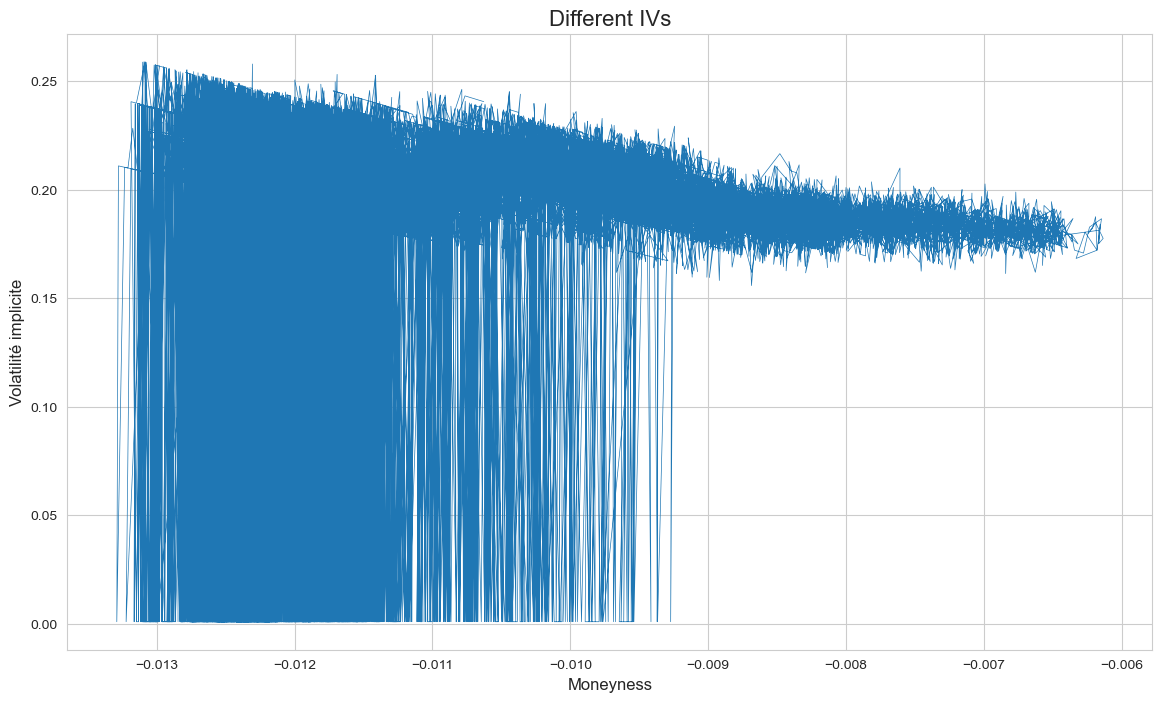

In [20]:
import seaborn as sns
plt.figure(figsize=(14, 8))
sns.set_style('whitegrid')


plt.plot(np.log(9750/voucher_9750_analysis['spot'])/voucher_9750_analysis['days_remaining'], voucher_9750_analysis['iv'], 
         label='Strike 9750', linewidth=.5)


# Ajouter des titres et des étiquettes
plt.title("Different IVs", fontsize=16)
plt.xlabel('Moneyness', fontsize=12)
plt.ylabel('Volatilité implicite', fontsize=12)

